# HDB Resale Flat Prices Insight Pipeline — Quick Guide

**Before you run anything, read the full HTML guide first:**

```
.\hdb_1\01_hdb_pipeline_guide.html
```

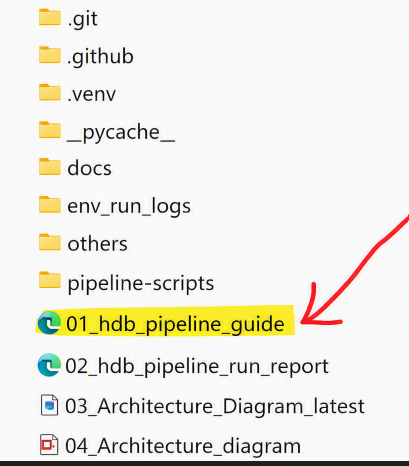

This notebook is just the short version — setup, run, watch, teardown.

## 1. Setup

In [ ]:
%%bash
cd hdb_1/pipeline-scripts/infrastructure_files/03_bash_scripts

export PROJECT_NAME=hdb-eventdriven
export HDB_ALERT_RECIPIENT_EMAILS=you@example.com

./setup.sh

Wait for:

```
SETUP COMPLETED SUCCESSFULLY
```

## 2. Run the pipeline

### Option A — real event-driven demo

Upload a file to:

```
s3://<bucket>/resale-flat-prices-manual-upload/
```

This automatically starts the pipeline. No CLI command needed.

### Option B — start ingestion from CLI

In [ ]:
%%bash
aws glue start-job-run --job-name hdb-job-1-ingestion-to-source

After Job 1 succeeds, EventBridge automatically starts the remaining pipeline.

## 3. Watch the pipeline

Go to:

**AWS Console → Step Functions → `hdb-eventdriven-pipeline`**

You should see:

```
Job 2 → Profiling → Job 3 → Job 4 → Job 5 → Compaction
```

---

**Execution running** — Step Functions console showing the pipeline execution in progress.

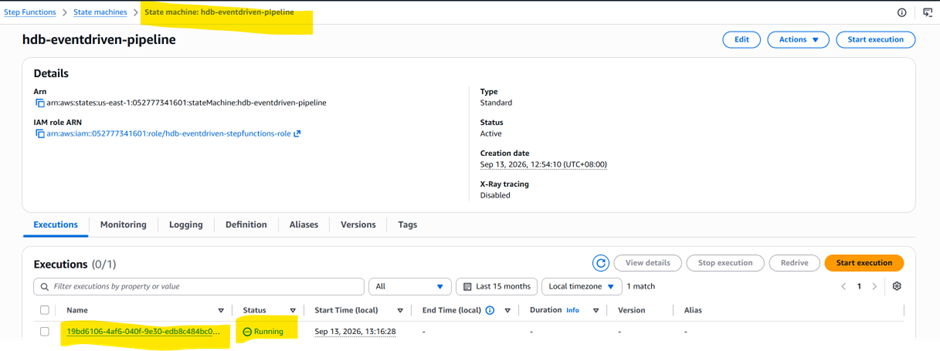

**Buckets created by `setup.sh`** — all `mission-hdb-eventdriven-052777341601-*` project buckets present.

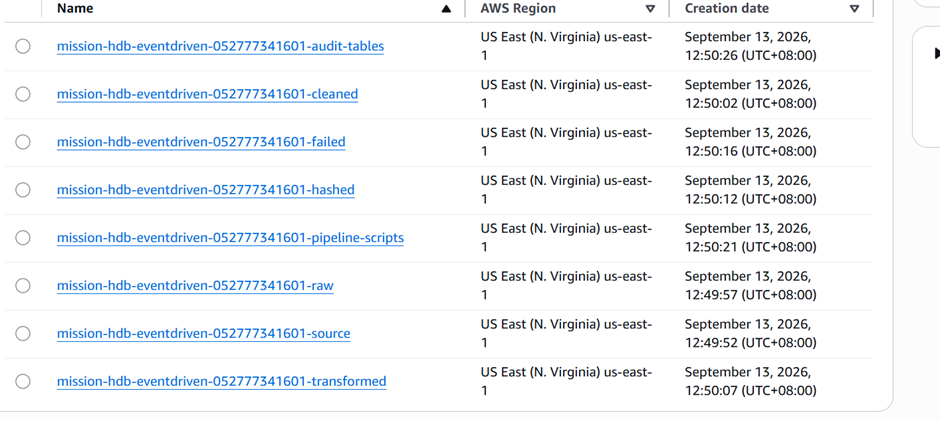

**`audit-tables` bucket structure** — includes the `alert-logs/` prefix.

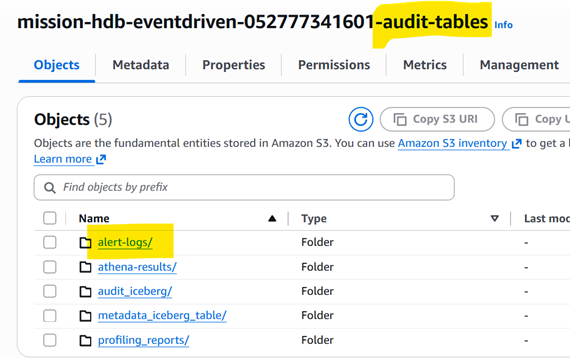

**`alert-logs/` fix confirmed** — `success/` and `failure/` subfolders exist (previously this prefix was wrongly swept as an orphan and deleted — see the `compact_iceberg_metadata.py` fix).

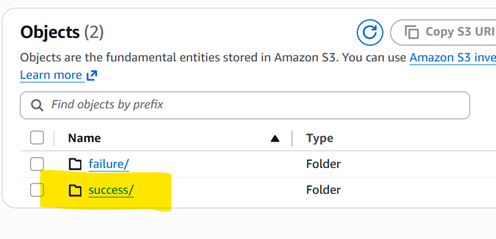

**Run report written on success** — the Lambda's per-run `.html`/`.md` report actually lands in `alert-logs/success/` now.

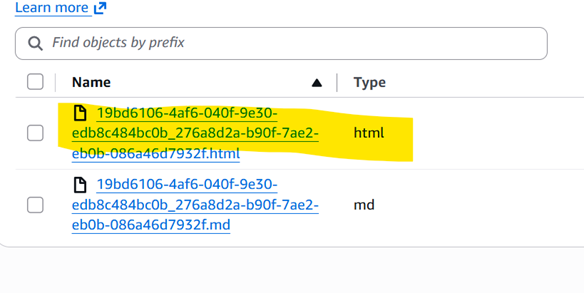

**Run summary after completion** — all 5 layers `SUCCEEDED` (job_2 through job_5), with the reject-reason breakdown by layer. This is the report written to `pipeline_runs` and emailed out via the success alert.

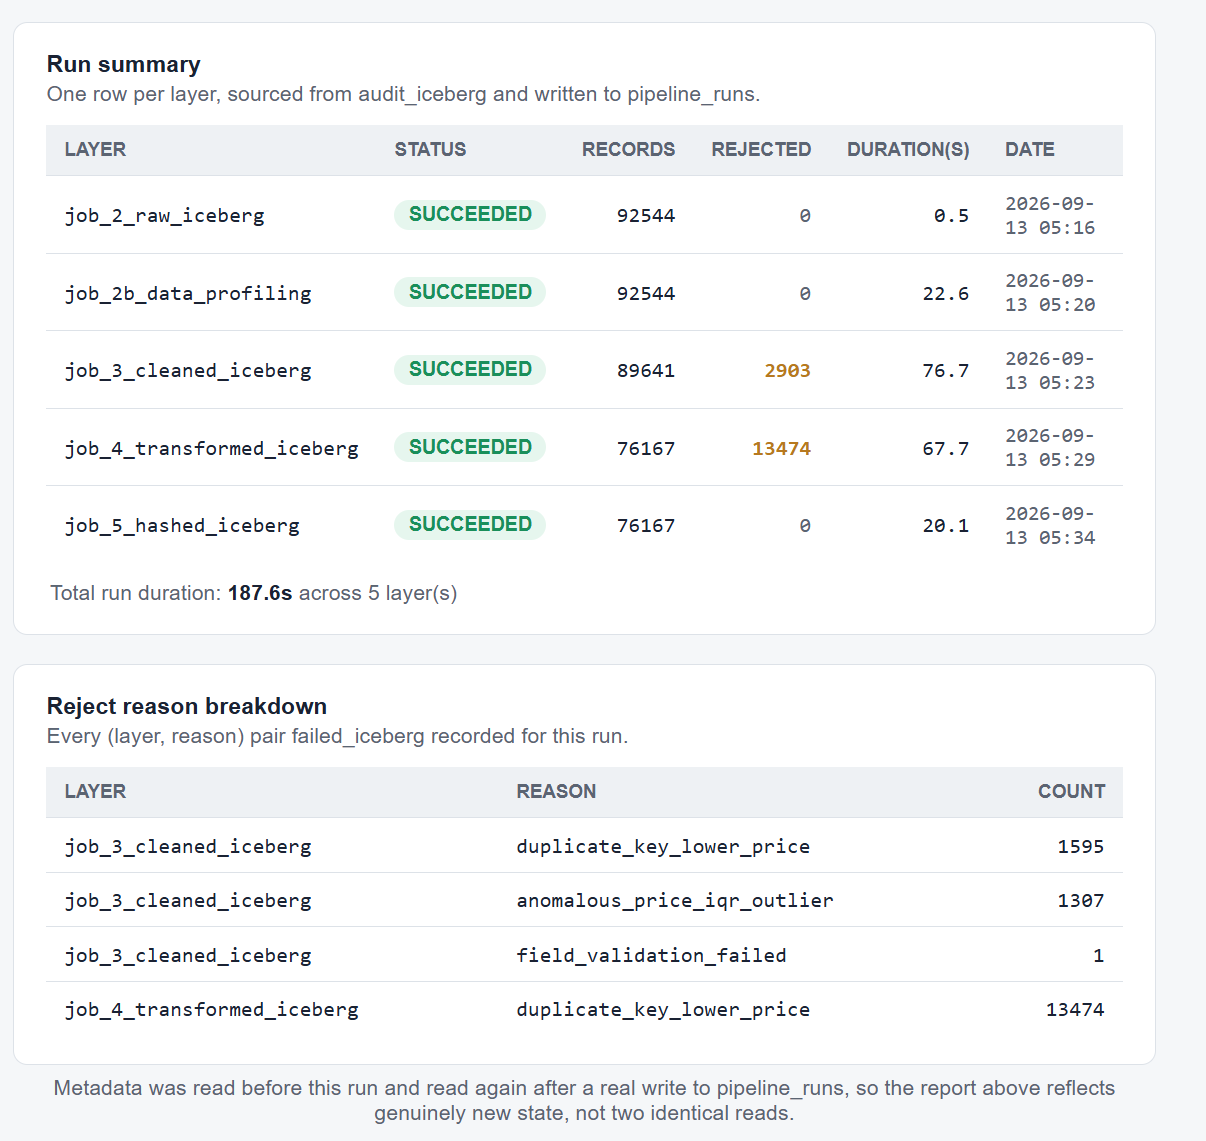


## 4. When finished

To avoid AWS charges:

In [ ]:
%%bash
cd hdb_1/pipeline-scripts/infrastructure_files/03_bash_scripts

PROJECT_NAME=hdb-eventdriven ./tear_down.sh

---
Continue from where you left off.